<a href="https://colab.research.google.com/github/BenCoop16/IS-477/blob/main/is477_proj_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install vaderSentiment


In [ ]:
import requests
import pandas as pd
import datetime
import time
import yfinance as yf
import time
from google.colab import files
from datetime import datetime, timedelta
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [ ]:
all_posts = []

start_date = datetime(2024, 1, 1)
end_date = datetime(2026, 1, 1)
posts_per_week = 30  # enough to get a reliable sentiment average per week

current = start_date
while current < end_date:
    next_week = current + timedelta(weeks=1)

    params = {
        "subreddit": "Bitcoin",
        "after": current.strftime("%Y-%m-%d"),
        "before": next_week.strftime("%Y-%m-%d"),
        "limit": posts_per_week,
        "sort": "asc"
    }

    response = requests.get("https://arctic-shift.photon-reddit.com/api/posts/search", params=params)
    batch = response.json().get('data') or []

    if batch:
        all_posts.extend(batch)

    print(f"Week of {current.date()}: {len(batch)} posts, total: {len(all_posts)}")
    current = next_week
    time.sleep(0.5)

Week of 2024-01-01: 30 posts, total: 30
Week of 2024-01-08: 30 posts, total: 60
Week of 2024-01-15: 30 posts, total: 90
Week of 2024-01-22: 30 posts, total: 120
Week of 2024-01-29: 30 posts, total: 150
Week of 2024-02-05: 30 posts, total: 180
Week of 2024-02-12: 30 posts, total: 210
Week of 2024-02-19: 30 posts, total: 240
Week of 2024-02-26: 30 posts, total: 270
Week of 2024-03-04: 30 posts, total: 300
Week of 2024-03-11: 30 posts, total: 330
Week of 2024-03-18: 30 posts, total: 360
Week of 2024-03-25: 30 posts, total: 390
Week of 2024-04-01: 30 posts, total: 420
Week of 2024-04-08: 30 posts, total: 450
Week of 2024-04-15: 30 posts, total: 480
Week of 2024-04-22: 30 posts, total: 510
Week of 2024-04-29: 30 posts, total: 540
Week of 2024-05-06: 30 posts, total: 570
Week of 2024-05-13: 30 posts, total: 600
Week of 2024-05-20: 30 posts, total: 630
Week of 2024-05-27: 30 posts, total: 660
Week of 2024-06-03: 30 posts, total: 690
Week of 2024-06-10: 30 posts, total: 720
Week of 2024-06-17:

In [ ]:
df_bitcoin = pd.DataFrame(all_posts)[['id', 'title', 'selftext', 'score', 'upvote_ratio', 'num_comments', 'created_utc', 'subreddit']]
df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['created_utc'], unit='s')
print(df_bitcoin.shape)

(3150, 9)


In [ ]:
df_bitcoin

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp
0,18vkhs0,Crypto Trading at Bybit! Sign up,[removed],1,1.00,0,1704067279,Bitcoin,2024-01-01 00:01:19
1,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.00,1,1704067351,Bitcoin,2024-01-01 00:02:31
2,18vkl5i,Crypto Trading at Bybit! Sign up at,[removed],1,1.00,1,1704067574,Bitcoin,2024-01-01 00:06:14
3,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.00,2,1704067808,Bitcoin,2024-01-01 00:10:08
4,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.00,7,1704068581,Bitcoin,2024-01-01 00:23:01
...,...,...,...,...,...,...,...,...,...
3145,1py9fuo,Disappointed,I bought last year at £80k and listened to ton...,0,0.42,71,1766973705,Bitcoin,2025-12-29 02:01:45
3146,1py9nqn,Bitcoin ETF 401k: The Great Awakening - How Yo...,[removed],1,1.00,0,1766974299,Bitcoin,2025-12-29 02:11:39
3147,1py9o3p,"The initial predicament of $90,000 was resolve...",,2,1.00,0,1766974326,Bitcoin,2025-12-29 02:12:06
3148,1py9vby,An interesting description of mining is it true?,,4083,0.98,188,1766974867,Bitcoin,2025-12-29 02:21:07


In [ ]:
df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")
df_price_clean = df_price.copy()
df_price_clean.columns = ['close', 'high', 'low', 'open', 'volume']
df_price_clean = df_price_clean.reset_index()
df_price_clean.columns = ['date', 'close', 'high', 'low', 'open', 'volume']
df_price_clean['date'] = pd.to_datetime(df_price_clean['date'])
df_price_clean['price_change'] = df_price_clean['close'].diff()
df_price_clean['price_pct_change'] = df_price_clean['close'].pct_change() * 100
df_price_clean.to_csv('crypto_prices_raw.csv', index=False)
print(df_price_clean.shape)
print(df_price_clean.head())

/tmp/ipykernel_1359/3247487521.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_price = yf.download("BTC-USD", start="2024-01-01", end="2026-01-01", interval="1wk")
[*********************100%***********************]  1 of 1 completed

(105, 8)
        date         close          high           low          open  \
0 2024-01-01  43943.097656  45899.707031  40813.535156  42280.234375   
1 2024-01-08  41796.269531  48969.371094  41724.613281  43948.707031   
2 2024-01-15  41545.785156  43566.273438  40297.457031  41715.066406   
3 2024-01-22  42035.593750  42797.175781  38521.894531  41553.652344   
4 2024-01-29  42583.582031  43838.945312  41818.332031  42030.914062   

         volume  price_change  price_pct_change  
0  202311773985           NaN               NaN  
1  259971819745  -2146.828125         -4.885473  
2  139135824835   -250.484375         -0.599298  
3  155314602893    489.808594          1.178961  
4  135184187433    547.988281          1.303629  


In [ ]:
df_price.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,43943.097656,45899.707031,40813.535156,42280.234375,202311773985
2024-01-08,41796.269531,48969.371094,41724.613281,43948.707031,259971819745
2024-01-15,41545.785156,43566.273438,40297.457031,41715.066406,139135824835
2024-01-22,42035.593750,42797.175781,38521.894531,41553.652344,155314602893
2024-01-29,42583.582031,43838.945312,41818.332031,42030.914062,135184187433


In [ ]:
###Data files acquired/created and uploaded to GitHub

In [ ]:
print(df_bitcoin.shape)
print(df_price.shape)
print(df_bitcoin.head())
print(df_price.head())

(3150, 9)
(105, 5)
        id                                              title  \
0  18vkhs0                   Crypto Trading at Bybit! Sign up   
1  18vkiob  Anyone using AI legitimately to trade better? ...   
2  18vkl5i                Crypto Trading at Bybit! Sign up at   
3  18vkngq                       ETF approval, demand change?   
4  18vkvy4  Mass Adoption after Mass Awareness - We are ge...   

                                            selftext  score  upvote_ratio  \
0                                          [removed]      1           1.0   
1  Is anyone actually using AI to improve their c...      1           1.0   
2                                          [removed]      1           1.0   
3  Has anyone looked at what the lagtime is betwe...      1           1.0   
4  Visiting Flagstaff for New Years and found my ...      1           1.0   

   num_comments  created_utc subreddit           timestamp  
0             0   1704067279   Bitcoin 2024-01-01 00:01:19  
1    

In [ ]:
print("Duplicates:", df_bitcoin.duplicated(subset='id').sum())
print("\nMissing values:")
print(df_bitcoin.isnull().sum())
print("\nRemoved posts (selftext is [removed]):", (df_bitcoin['selftext'] == '[removed]').sum())
print("Deleted posts (selftext is [deleted]):", (df_bitcoin['selftext'] == '[deleted]').sum())

Duplicates: 0

Missing values:
id              0
title           0
selftext        0
score           0
upvote_ratio    0
num_comments    0
created_utc     0
subreddit       0
timestamp       0
dtype: int64

Removed posts (selftext is [removed]): 820
Deleted posts (selftext is [deleted]): 12


In [ ]:
df_bitcoin_clean = df_bitcoin[df_bitcoin['selftext'] != '[removed]']
df_bitcoin_clean = df_bitcoin_clean[df_bitcoin_clean['selftext'] != '[deleted]']
df_bitcoin_clean = df_bitcoin_clean.reset_index(drop=True)
print(df_bitcoin_clean.shape)

(2318, 9)


In [ ]:
print("Duplicates:", df_price.duplicated().sum())
print("\nMissing values:")
print(df_price.isnull().sum())
print("\nPrice data types:")
print(df_price.dtypes)

Duplicates: 0

Missing values:
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Price data types:
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object


In [ ]:
df_price_clean = df_price.copy()
df_price_clean.columns = ['close', 'high', 'low', 'open', 'volume']
df_price_clean = df_price_clean.reset_index()
df_price_clean.columns = ['date', 'close', 'high', 'low', 'open', 'volume']
df_price_clean['date'] = pd.to_datetime(df_price_clean['date'])
print(df_price_clean.head())
print(df_price_clean.dtypes)

        date         close          high           low          open  \
0 2024-01-01  43943.097656  45899.707031  40813.535156  42280.234375   
1 2024-01-08  41796.269531  48969.371094  41724.613281  43948.707031   
2 2024-01-15  41545.785156  43566.273438  40297.457031  41715.066406   
3 2024-01-22  42035.593750  42797.175781  38521.894531  41553.652344   
4 2024-01-29  42583.582031  43838.945312  41818.332031  42030.914062   

         volume  
0  202311773985  
1  259971819745  
2  139135824835  
3  155314602893  
4  135184187433  
date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume             int64
dtype: object


In [ ]:
df_bitcoin_clean['date'] = df_bitcoin_clean['timestamp'].dt.normalize()
df_daily_reddit = df_bitcoin_clean.groupby('date').agg(
    post_count=('id', 'count'),
    avg_score=('score', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    avg_comments=('num_comments', 'mean')
).reset_index()
print(df_daily_reddit.shape)
print(df_daily_reddit.head())

(105, 5)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments
0 2024-01-01          24   1.000000          0.958333     20.125000
1 2024-01-08          24  38.625000          0.686250     26.458333
2 2024-01-15          26  37.423077          0.616923     20.307692
3 2024-01-22          24   6.625000          0.708750     14.458333
4 2024-01-29          25   9.080000          0.649200     13.560000


In [ ]:
print("Reddit date range:")
print(df_bitcoin_clean['timestamp'].min())
print(df_bitcoin_clean['timestamp'].max())

Reddit date range:
2024-01-01 00:02:31
2025-12-29 02:27:26


In [ ]:
df_price_monthly = df_price_clean.copy()
df_price_monthly['date'] = df_price_monthly['date'].dt.to_period('M').dt.to_timestamp()
df_price_monthly = df_price_monthly.groupby('date').agg(
    avg_close=('close', 'mean'),
    avg_volume=('volume', 'mean'),
    price_change=('close', lambda x: x.iloc[-1] - x.iloc[0])
).reset_index()
df_merged = pd.merge(df_daily_reddit, df_price_monthly, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(5, 8)
        date  post_count   avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24    1.000000          0.958333     20.125000   
1 2024-04-01          24    4.458333          0.648750      6.250000   
2 2024-07-01          22   17.954545          0.610000     26.863636   
3 2025-09-01          23   51.565217          0.635217     26.695652   
4 2025-12-01          26  258.269231          0.737308     32.307692   

       avg_close    avg_volume  price_change  
0   42380.865625  1.783836e+11  -1359.515625  
1   65434.457812  2.338617e+11  -5331.421875  
2   62232.853906  2.201888e+11   2267.867188  
3  115503.496875  3.575124e+11  12345.859375  
4   88754.078125  3.013593e+11  -1673.656250  


In [ ]:
df_bitcoin_clean.to_csv('reddit_bitcoin_clean.csv', index=False)
df_price_clean.to_csv('crypto_prices_clean.csv', index=False)
df_merged.to_csv('merged_data.csv', index=False)
print("All files saved!")

All files saved!


In [ ]:
analyzer = SentimentIntensityAnalyzer()
df_bitcoin_clean['sentiment'] = df_bitcoin_clean['title'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
print(df_bitcoin_clean[['title', 'sentiment']].head(10))

                                               title  sentiment
0  Anyone using AI legitimately to trade better? ...     0.4404
1                       ETF approval, demand change?     0.3818
2  Mass Adoption after Mass Awareness - We are ge...     0.0000
3                                Bitcoin Yearly Lows    -0.2023
4                       Happy new year motherfuckers     0.5719
5  On the Lightning Network does the node operato...     0.3400
6                              This is where it ends     0.0000
7  Best place to store your Bitcoin from Coinbase...     0.8442
8  Yo why the Bitcoin fees so high right now is t...     0.0000
9                             Happy new year to all!     0.6114


In [ ]:
def label_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_bitcoin_clean['sentiment_label'] = df_bitcoin_clean['sentiment'].apply(label_sentiment)
print(df_bitcoin_clean['sentiment_label'].value_counts())

sentiment_label
neutral     1344
positive     621
negative     353
Name: count, dtype: int64


In [ ]:
df_daily_reddit = df_bitcoin_clean.groupby('date').agg(
    post_count=('id', 'count'),
    avg_score=('score', 'mean'),
    avg_upvote_ratio=('upvote_ratio', 'mean'),
    avg_comments=('num_comments', 'mean'),
    avg_sentiment=('sentiment', 'mean'),
    positive_ratio=('sentiment_label', lambda x: (x == 'positive').sum() / len(x)),
    negative_ratio=('sentiment_label', lambda x: (x == 'negative').sum() / len(x))
).reset_index()

print(df_daily_reddit.shape)
print(df_daily_reddit.head())

(105, 8)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio  
0       0.246454        0.500000        0.041667  
1       0.133475        0.333333        0.041667  
2       0.103381        0.346154        0.038462  
3       0.036675        0.291667        0.250000  
4       0.019376        0.320000        0.120000  


In [ ]:
df_price_clean['price_change'] = df_price_clean['close'].diff()
df_price_clean['price_pct_change'] = df_price_clean['close'].pct_change() * 100

df_merged = pd.merge(df_daily_reddit, df_price_clean, on='date', how='inner')
print(df_merged.shape)
print(df_merged.head())

(105, 15)
        date  post_count  avg_score  avg_upvote_ratio  avg_comments  \
0 2024-01-01          24   1.000000          0.958333     20.125000   
1 2024-01-08          24  38.625000          0.686250     26.458333   
2 2024-01-15          26  37.423077          0.616923     20.307692   
3 2024-01-22          24   6.625000          0.708750     14.458333   
4 2024-01-29          25   9.080000          0.649200     13.560000   

   avg_sentiment  positive_ratio  negative_ratio         close          high  \
0       0.246454        0.500000        0.041667  43943.097656  45899.707031   
1       0.133475        0.333333        0.041667  41796.269531  48969.371094   
2       0.103381        0.346154        0.038462  41545.785156  43566.273438   
3       0.036675        0.291667        0.250000  42035.593750  42797.175781   
4       0.019376        0.320000        0.120000  42583.582031  43838.945312   

            low          open        volume  price_change  price_pct_change  
0  4

In [ ]:
from scipy import stats

sentiment_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count', 'avg_score']
price_cols = ['close', 'price_change', 'price_pct_change', 'volume']

print('=== Pearson Correlation ===')
for sc in sentiment_cols:
    for pc in price_cols:
        subset = df_merged[[sc, pc]].dropna()
        r, p = stats.pearsonr(subset[sc], subset[pc])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {sc:25s} vs {pc:20s}: r={r:+.4f}, p={p:.4f} {sig}')

=== Pearson Correlation ===
  avg_sentiment             vs close               : r=-0.2146, p=0.0280 *
  avg_sentiment             vs price_change        : r=-0.0177, p=0.8586 
  avg_sentiment             vs price_pct_change    : r=-0.0436, p=0.6603 
  avg_sentiment             vs volume              : r=-0.1950, p=0.0462 *
  positive_ratio            vs close               : r=-0.1826, p=0.0623 
  positive_ratio            vs price_change        : r=-0.0579, p=0.5593 
  positive_ratio            vs price_pct_change    : r=-0.0825, p=0.4051 
  positive_ratio            vs volume              : r=-0.2417, p=0.0130 *
  negative_ratio            vs close               : r=+0.1974, p=0.0435 *
  negative_ratio            vs price_change        : r=-0.0261, p=0.7925 
  negative_ratio            vs price_pct_change    : r=-0.0007, p=0.9941 
  negative_ratio            vs volume              : r=+0.0666, p=0.4995 
  post_count                vs close               : r=-0.2005, p=0.0403 *
  pos

In [ ]:
print('=== Lag Correlation: avg_sentiment vs. future price_pct_change ===')
lag_results = []
for lag in range(0, min(8, len(df_merged) - 1)):
    df_lag = df_merged[['avg_sentiment', 'price_pct_change']].copy()
    df_lag['future_price_change'] = df_lag['price_pct_change'].shift(-lag)
    subset = df_lag.dropna()
    if len(subset) < 2:
        print(f'  Lag {lag} days: not enough data')
        continue
    r, p = stats.pearsonr(subset['avg_sentiment'], subset['future_price_change'])
    lag_results.append({'lag_days': lag, 'pearson_r': r, 'p_value': p})
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  Lag {lag} days: r={r:+.4f}, p={p:.4f} {sig}')

df_lag_results = pd.DataFrame(lag_results)

=== Lag Correlation: avg_sentiment vs. future price_pct_change ===
  Lag 0 days: r=-0.0436, p=0.6603 
  Lag 1 days: r=-0.0772, p=0.4381 
  Lag 2 days: r=+0.0826, p=0.4090 
  Lag 3 days: r=+0.1815, p=0.0693 
  Lag 4 days: r=-0.0145, p=0.8863 
  Lag 5 days: r=-0.1668, p=0.0990 
  Lag 6 days: r=+0.0731, p=0.4744 
  Lag 7 days: r=+0.0935, p=0.3622 


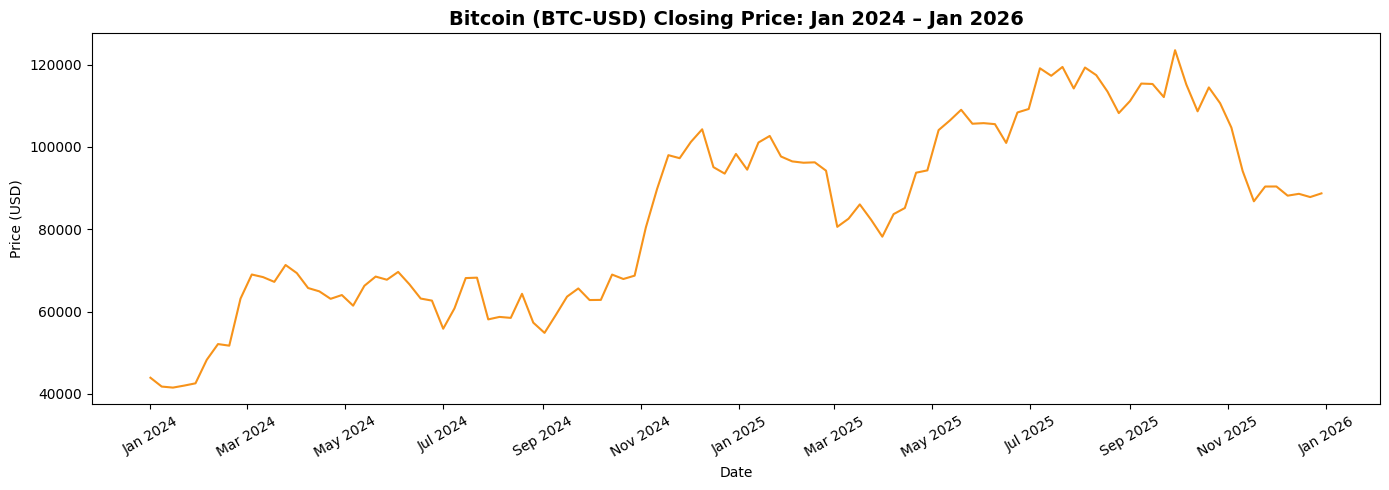

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5)
ax.set_title('Bitcoin (BTC-USD) Closing Price: Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig1_btc_price.png', dpi=150)
plt.show()

In [ ]:
df_bitcoin_clean

,id,title,selftext,score,upvote_ratio,num_comments,created_utc,subreddit,timestamp,date,sentiment,sentiment_label
0,18vkiob,Anyone using AI legitimately to trade better? ...,Is anyone actually using AI to improve their c...,1,1.00,1,1704067351,Bitcoin,2024-01-01 00:02:31,2024-01-01,0.4404,positive
1,18vkngq,"ETF approval, demand change?",Has anyone looked at what the lagtime is betwe...,1,1.00,2,1704067808,Bitcoin,2024-01-01 00:10:08,2024-01-01,0.3818,positive
2,18vkvy4,Mass Adoption after Mass Awareness - We are ge...,Visiting Flagstaff for New Years and found my ...,1,1.00,7,1704068581,Bitcoin,2024-01-01 00:23:01,2024-01-01,0.0000,neutral
3,18vkxzr,Bitcoin Yearly Lows,2012 - $4\n\n2013 - $65\n\n2014 - $200\n\n2015...,1,1.00,138,1704068769,Bitcoin,2024-01-01 00:26:09,2024-01-01,-0.2023,negative
4,18vkyzb,Happy new year motherfuckers,2023 was a good year. It was also a shitty yea...,1,1.00,4,1704068862,Bitcoin,2024-01-01 00:27:42,2024-01-01,0.5719,positive
...,...,...,...,...,...,...,...,...,...,...,...,...
2313,1py995l,"If in doubt, zoom out…",,283,0.91,39,1766973207,Bitcoin,2025-12-29 01:53:27,2025-12-29,-0.3612,negative
2314,1py9fuo,Disappointed,I bought last year at £80k and listened to ton...,0,0.42,71,1766973705,Bitcoin,2025-12-29 02:01:45,2025-12-29,-0.4767,negative
2315,1py9o3p,"The initial predicament of $90,000 was resolve...",,2,1.00,0,1766974326,Bitcoin,2025-12-29 02:12:06,2025-12-29,0.1779,positive
2316,1py9vby,An interesting description of mining is it true?,,4083,0.98,188,1766974867,Bitcoin,2025-12-29 02:21:07,2025-12-29,0.6705,positive


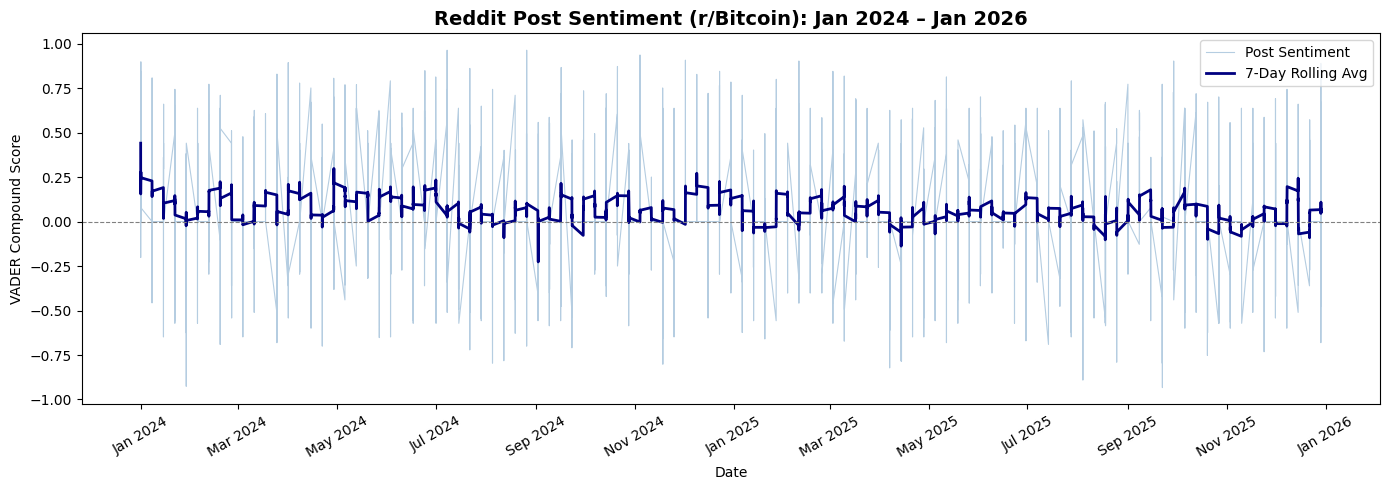

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_bitcoin_clean['timestamp'], df_bitcoin_clean['sentiment'],
        color='steelblue', linewidth=0.8, alpha=0.4, label='Post Sentiment')
rolling = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax.plot(rolling.index, rolling.values, color='navy', linewidth=2, label='7-Day Rolling Avg')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Reddit Post Sentiment (r/Bitcoin): Jan 2024 – Jan 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('VADER Compound Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig2_sentiment_over_time.png', dpi=150)
plt.show()

In [ ]:
print(df_bitcoin_clean['date'].min())
print(df_bitcoin_clean['date'].max())
print(df_bitcoin_clean['date'].nunique())

2024-01-01 00:00:00
2025-12-29 00:00:00
105


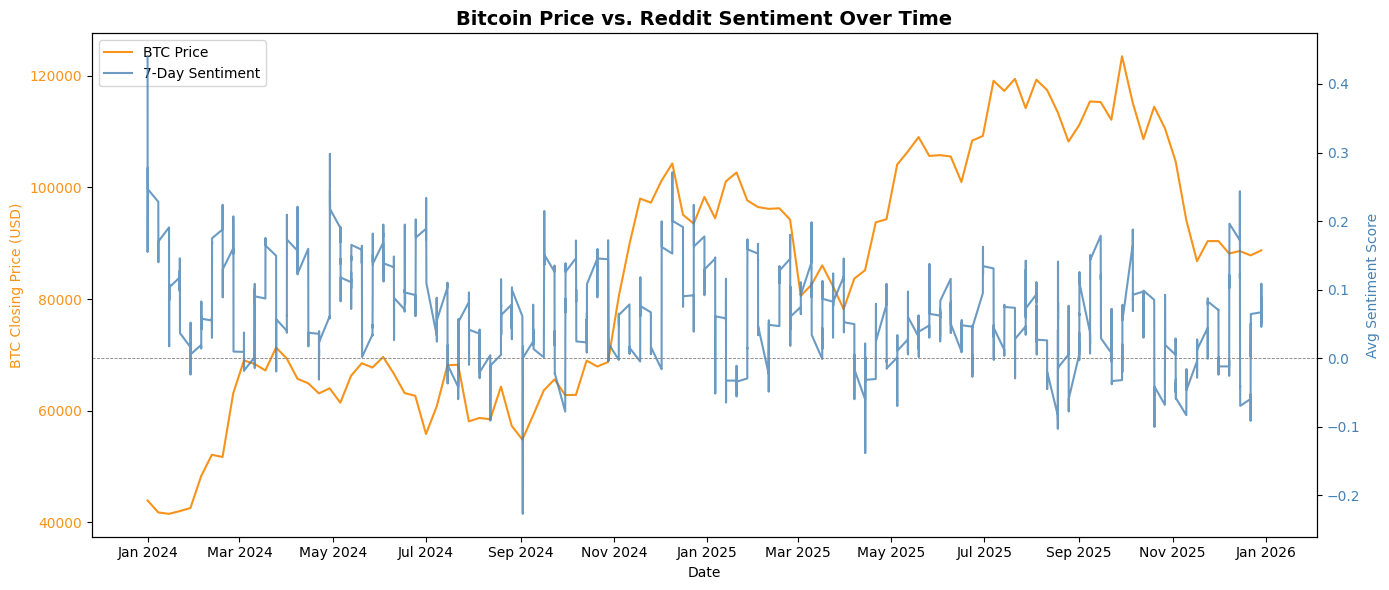

In [ ]:
df_bitcoin_clean['date'] = pd.to_datetime(df_bitcoin_clean['timestamp']).dt.normalize()
df_post_merged = pd.merge(df_bitcoin_clean[['date', 'sentiment']], df_price_clean[['date', 'close']], on='date', how='inner')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(df_price_clean['date'], df_price_clean['close'], color='#F7931A', linewidth=1.5, label='BTC Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('BTC Closing Price (USD)', color='#F7931A')
ax1.tick_params(axis='y', labelcolor='#F7931A')

ax2 = ax1.twinx()
rolling_s = df_bitcoin_clean.set_index('timestamp')['sentiment'].rolling('7D').mean()
ax2.plot(rolling_s.index, rolling_s.values, color='steelblue', linewidth=1.5, alpha=0.8, label='7-Day Sentiment')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax2.set_ylabel('Avg Sentiment Score', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Bitcoin Price vs. Reddit Sentiment Over Time', fontsize=14, fontweight='bold')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig3_price_vs_sentiment.png', dpi=150)
plt.show()

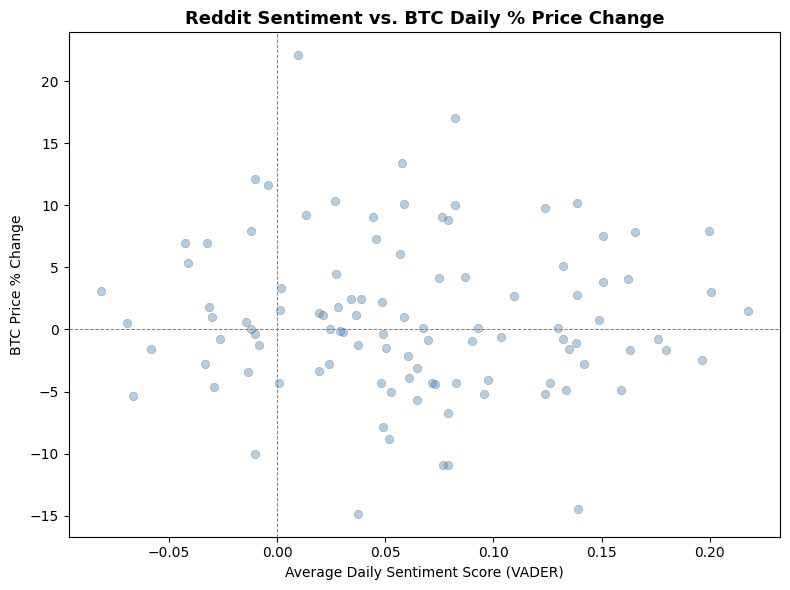

In [ ]:
import numpy as np

subset = df_merged[['avg_sentiment', 'price_pct_change']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(subset['avg_sentiment'], subset['price_pct_change'],
           alpha=0.4, edgecolors='k', linewidths=0.3, color='steelblue')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)
ax.set_title('Reddit Sentiment vs. BTC Daily % Price Change', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Daily Sentiment Score (VADER)')
ax.set_ylabel('BTC Price % Change')
plt.tight_layout()
plt.savefig('fig4_scatter_sentiment_vs_price.png', dpi=150)
plt.show()

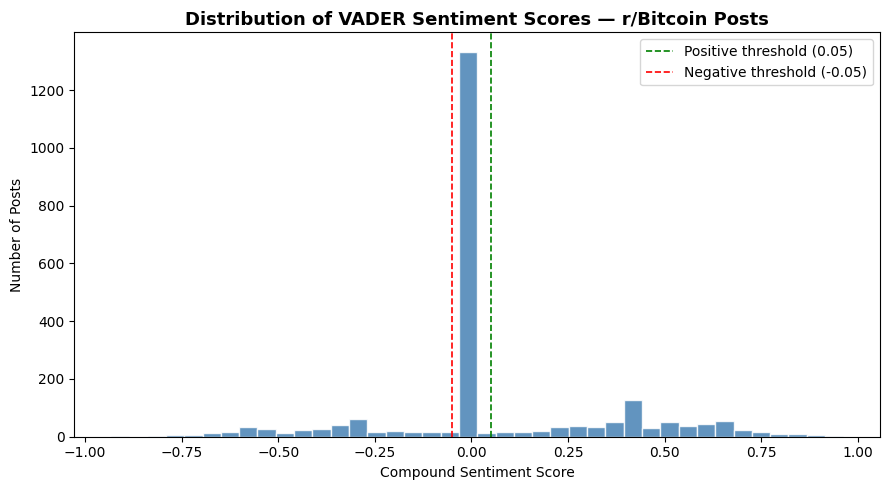

Positive: 621 posts (26.8%)
Neutral: 1344 posts (58.0%)
Negative: 353 posts (15.2%)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_bitcoin_clean['sentiment'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0.05, color='green', linestyle='--', linewidth=1.2, label='Positive threshold (0.05)')
ax.axvline(-0.05, color='red', linestyle='--', linewidth=1.2, label='Negative threshold (-0.05)')
ax.set_title('Distribution of VADER Sentiment Scores — r/Bitcoin Posts', fontsize=13, fontweight='bold')
ax.set_xlabel('Compound Sentiment Score')
ax.set_ylabel('Number of Posts')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_sentiment_distribution.png', dpi=150)
plt.show()

counts = df_bitcoin_clean['sentiment_label'].value_counts()
total = len(df_bitcoin_clean)
for label in ['positive', 'neutral', 'negative']:
    n = counts.get(label, 0)
    print(f'{label.capitalize()}: {n} posts ({n/total*100:.1f}%)')

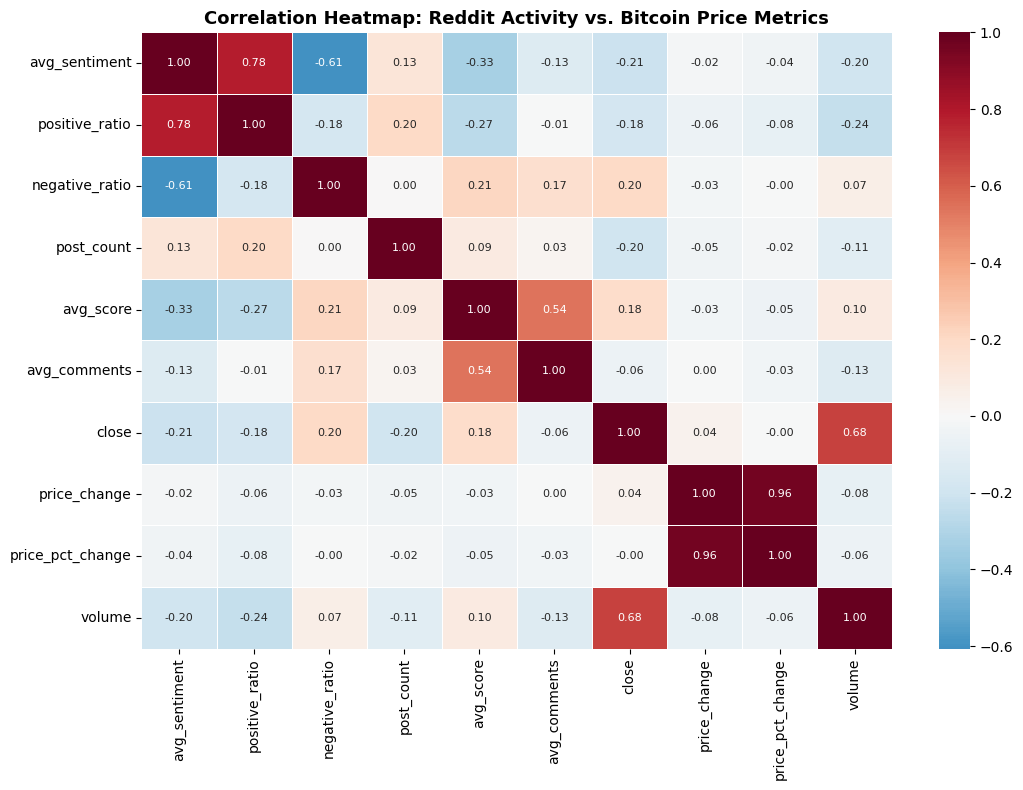

In [ ]:
import seaborn as sns
heatmap_cols = ['avg_sentiment', 'positive_ratio', 'negative_ratio', 'post_count',
                'avg_score', 'avg_comments', 'close', 'price_change', 'price_pct_change', 'volume']
corr_matrix = df_merged[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap: Reddit Activity vs. Bitcoin Price Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', dpi=150)
plt.show()

/tmp/ipykernel_1359/590628670.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_post_price, x='sentiment_label', y='price_pct_change',


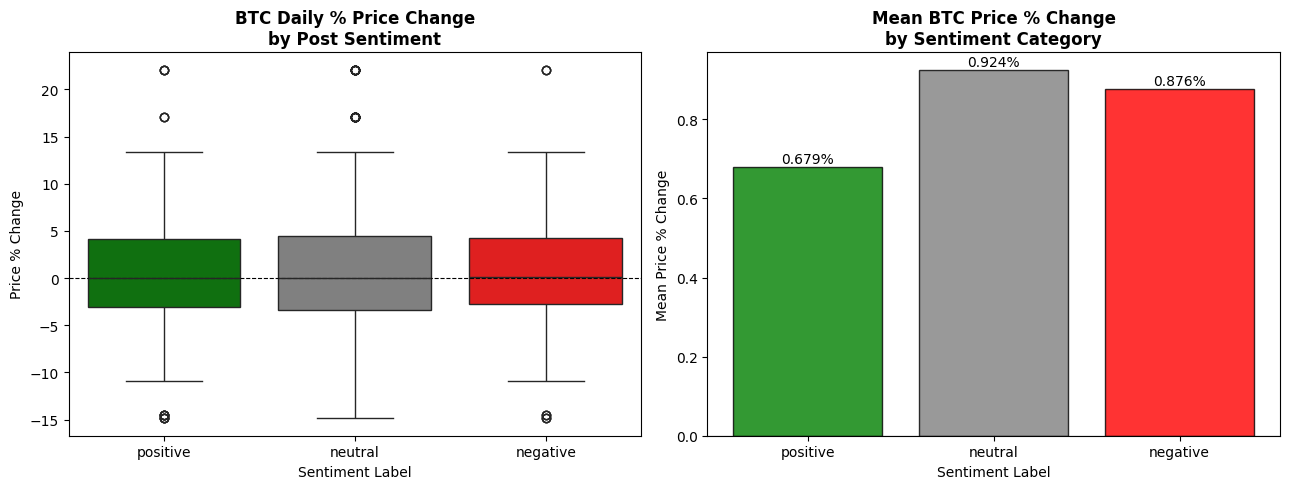

In [ ]:
df_post_price = pd.merge(
    df_bitcoin_clean[['date', 'sentiment_label']],
    df_price_clean[['date', 'close', 'price_pct_change']],
    on='date', how='inner'
)

order = ['positive', 'neutral', 'negative']
palette = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_post_price, x='sentiment_label', y='price_pct_change',
            order=order, palette=palette, ax=axes[0])
axes[0].set_title('BTC Daily % Price Change\nby Post Sentiment', fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Price % Change')
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)

means = df_post_price.groupby('sentiment_label')['price_pct_change'].mean().reindex(order)
bars = axes[1].bar(means.index, means.values,
                   color=[palette[k] for k in means.index], alpha=0.8, edgecolor='k')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Mean BTC Price % Change\nby Sentiment Category', fontweight='bold')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Mean Price % Change')
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig8_price_by_sentiment_category.png', dpi=150)
plt.show()

In [ ]:
from scipy import stats

# ── RQ1: Avg daily sentiment vs BTC price change at 1-, 2-, 3-day lags ──
print("RQ1: Avg Daily Sentiment vs. Future BTC Price % Change")
for lag in [1, 2, 3]:
    df_merged[f'lag{lag}'] = df_merged['price_pct_change'].shift(-lag)
    subset = df_merged[['avg_sentiment', f'lag{lag}']].dropna()
    r, p = stats.pearsonr(subset['avg_sentiment'], subset[f'lag{lag}'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"  Lag {lag} day(s): r = {r:+.4f}, p = {p:.4f} {sig} (n={len(subset)})")

# ── RQ2: High-upvote (>75th pct) vs low-upvote sentiment → next-day price ──
q75 = df_merged['avg_score'].quantile(0.75)
df_merged['next_day_pct'] = df_merged['price_pct_change'].shift(-1)

print(f"\nRQ2: High vs. Low Upvote Posts vs. Next-Day BTC Price (75th pct = {q75:.0f})")
for label, group in [('High (>75th pct)', df_merged[df_merged['avg_score'] > q75]),
                     ('Low (<=75th pct)', df_merged[df_merged['avg_score'] <= q75])]:
    subset = group[['avg_sentiment', 'next_day_pct']].dropna()
    r, p = stats.pearsonr(subset['avg_sentiment'], subset['next_day_pct'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"  {label}: r = {r:+.4f}, p = {p:.4f} {sig} (n={len(subset)})")

RQ1: Avg Daily Sentiment vs. Future BTC Price % Change
  Lag 1 day(s): r = -0.0978, p = 0.3234 n.s. (n=104)
  Lag 2 day(s): r = +0.0736, p = 0.4603 n.s. (n=103)
  Lag 3 day(s): r = +0.1762, p = 0.0765 n.s. (n=102)

RQ2: High vs. Low Upvote Posts vs. Next-Day BTC Price (75th pct = 94)
  High (>75th pct): r = -0.2163, p = 0.2990 n.s. (n=25)
  Low (<=75th pct): r = -0.0370, p = 0.7462 n.s. (n=79)


## Findings

**RQ1: Does average daily r/Bitcoin sentiment correlate with Bitcoin's closing price change within a 1–3 day window?**

No statistically significant correlation was found at any lag. Pearson correlations between average daily sentiment and future BTC price % change were weak across all three windows (lag 1: r = -0.10, p = 0.32; lag 2: r = +0.07, p = 0.46; lag 3: r = +0.18, p = 0.08), with none reaching the p < 0.05 threshold. Notably, the lag 3 result approached significance with the largest effect size observed, suggesting a weak delayed relationship may be worth exploring with a larger sample. Overall, r/Bitcoin sentiment alone does not appear to be a reliable short-term predictor of Bitcoin price movement.

**RQ2: Do posts with upvote scores above the 75th percentile show a stronger correlation with next-day Bitcoin price movements?**

High-upvote posts (score > 94) did show a slightly stronger correlation with next-day price change (r = -0.22, p = 0.30, n=25) compared to low-upvote posts (r = -0.04, p = 0.75, n=79), but neither result was statistically significant. The smaller sample size of high-upvote posts limits the reliability of this comparison. While the direction of the effect is consistent — higher-engagement posts trending negative relative to next-day returns — no conclusive evidence supports the hypothesis that upvote score amplifies predictive signal.

**Overall:** Across both research questions, the results suggest that Reddit sentiment from r/Bitcoin does not significantly predict short-term Bitcoin price movements in this dataset. The weak, non-significant correlations may reflect the noisy, speculative nature of crypto markets, the limitations of title-only VADER sentiment analysis, or the need for a longer or denser post dataset to detect subtler effects.